In [ ]:
import time
from dataclasses import dataclass, field
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import erfc

# Comparative Analysis of Turbo and LDPC Codes

## Abstract

Turbo Codes and Low-Density Parity-Check (LDPC) Codes are advanced forward error correction (FEC) techniques used in modern digital communication systems to improve reliability over noisy channels. This project performs a comparative analysis of Turbo and LDPC codes, focusing on Bit Error Rate (BER), decoding complexity, and convergence behavior under controlled conditions. Both codes are simulated over an Additive White Gaussian Noise (AWGN) channel with Binary Phase Shift Keying (BPSK) modulation. Metrics such as BER, decoding time, iteration count, and code rate are evaluated. The study aims to determine under which conditions each coding scheme outperforms the other, providing insights into their practical trade-offs and application in 4G and 5G systems.

## Introduction

Reliable data transmission is a fundamental requirement in modern digital communication systems. During transmission over a communication channel, signals are inevitably affected by noise, interference, and other impairments that may introduce errors in the received data. In order to ensure accurate information recovery, communication systems employ error control techniques that can detect and correct errors during transmission.

Forward Error Correction (FEC) is one of the most important approaches used to improve reliability in digital communication. FEC techniques add structured redundancy to the transmitted data, allowing the receiver to identify and correct errors without the need for retransmission. Over the past decades, many coding techniques have been developed. Two of them are **Turbo Codes** and **Low-Density Parity-Check (LDPC) Codes**.

Turbo codes were introduced in the 1990s and quickly gained attention because of their ability to achieve performance close to the theoretical limits defined by Shannon’s channel capacity theorem. Due to their excellent performance, Turbo codes were adopted in communication standards, including third-generation (3G) and fourth-generation (4G) cellular systems.

Low-Density Parity-Check (LDPC) codes, proposed earlier but later rediscovered and improved, have become powerful error correction techniques in modern communication systems. Their parallel decoding structure and strong error-correcting capabilities make them suitable for high-throughput applications. As a result, LDPC codes were adopted in many modern standards, including Wi-Fi, satellite communications, and fifth-generation (5G) mobile networks.

The transition from Turbo codes to LDPC codes in newer communication standards raises important questions regarding their relative performance, complexity, and efficiency under different communication conditions. Understanding these differences is essential for evaluating the suitability of each coding scheme for specific applications.

The purpose of this study is to perform a comparative analysis between Turbo and LDPC codes under controlled simulation conditions. Both coding techniques are evaluated using a digital communication model that includes Binary Phase Shift Keying (BPSK) modulation and an Additive White Gaussian Noise (AWGN) channel. The performance of the two coding schemes is analyzed using several key metrics, including Bit Error Rate (BER), decoding iterations, and computational complexity.

The main objective of this work is to investigate the conditions under which coding technique performs more efficiently.

## Theoretical Background

### Information Theory

Information theory studies the limits of transmitting and processing information, particularly in the presence of noise and interference. Introduced by Claude Shannon in 1948, it provides the mathematical framework for understanding how data can be reliably communicated over imperfect channels. One of its most important concepts is channel capacity, which represents the maximum data rate at which information can be transmitted with an arbitrarily low probability of error.

### Coding Theory

Coding theory builds upon information theory and focuses on designing methods that allow reliable communication by adding structured redundancy to transmitted data. These methods, known as error-correcting codes, enable the detection and correction of errors caused by noise or interference in communication channels. Techniques developed within coding theory, including modern approaches such as Turbo codes and Low-Density Parity-Check (LDPC) codes, play a crucial role in achieving reliable and efficient digital communication systems.

### Communication Channel Model

A communication channel model represents the medium through which information is transmitted from a sender to a receiver. In digital communication systems, the transmitted signal may be affected by noise, interference, attenuation, and other distortions that can alter the original data. To analyze and evaluate communication systems, mathematical models of channels are used to simulate how signals are modified during transmission. These models allow researchers to study the performance of different encoding and decoding techniques under controlled conditions.

One of the most commonly used models in communication theory is the Additive White Gaussian Noise (AWGN) channel. In this model, the transmitted signal is corrupted by Gaussian noise that is randomly added to the signal during transmission. The AWGN model is widely used because it provides a simple yet effective way to represent many real-world communication environments. In this study, the AWGN channel model is used together with Binary Phase Shift Keying (BPSK) modulation to evaluate the performance of Turbo and LDPC codes under noisy transmission conditions.

### Error Detection and Corrrection

**Error correction** is a process used to detect and fix mistakes in data during transmission or storage, without the need to resend the information. It is particularly important in situations where retransmission is difficult, slow, or expensive. By automatically correcting errors at the receiver, communication systems can ensure that the data they deliver is accurate and dependable. The primary techniques are **Automatic Repeat Request (ARQ)**, **Forward Error Correction (FEC)** and **Hybrid ARQ**. ARQ relies on feedback from the receiver to request retransmission of wrong data, with common variants including **Stop-and-Wait**, **Go-Back-N**, and **Selective Repeat**, making it suitable for networks where retransmission is feasible, such as TCP/IP. FEC, on the other hand, adds redundancy to the transmitted data so that the receiver can detect and correct errors without needing a resend, which is essential for real-time or high-latency applications like voice over IP, video streaming or satellite communication. Important FEC codes include **block codes** (e.g., Hamming, Reed–Solomon), **convolutional codes** (decoded via the Viterbi algorithm), **repetition codes** and **burst error-correcting codes**. Hybrid ARQ combines both approaches by transmitting data with FEC parity information and using retransmission via ARQ only when FEC fails, providing an efficient balance of reliability and speed in modern wireless and high-speed networks.

**Error detection**, on the other hand, focuses on identifying whether errors have occurred in the transmitted or stored data. Its main purpose is to verify that the received data matches what was originally sent. Although it does not correct the errors, it plays a crucial role in maintaining data integrity by alerting the system when errors are present so appropriate actions, such as retransmission, can be taken. Common techniques include:
- **Parity Bits:** This simple approach adds a single extra bit to a data block to make the total number of 1s either even (even parity) or odd (odd parity). It can detect single-bit errors effectively.

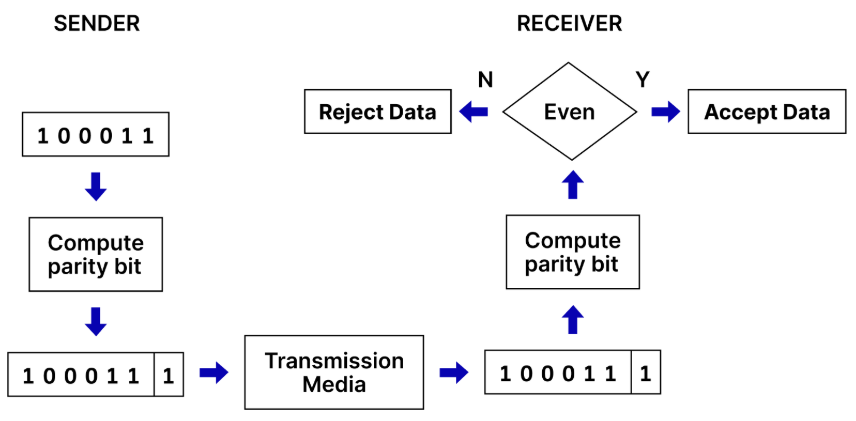

- **Checksums:** It is calculated by summing the data values before transmission. At the receiver, the checksum is recomputed and compared with the original. A mismatch indicates that an error has occurred.

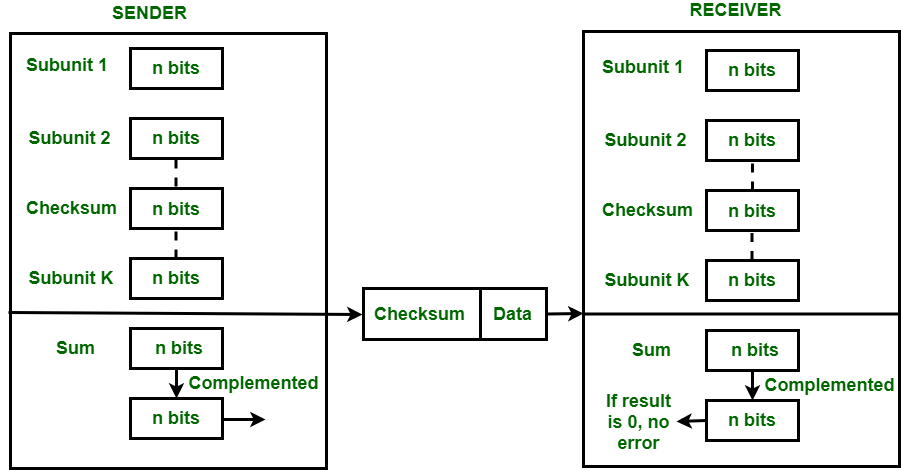

- **Cyclic Redundancy Check (CRC):** CRC uses polynomial division to generate a code that can detect accidental changes to raw data. It is more robust than simple parity or checksums and is widely used in networking protocols and data storage.

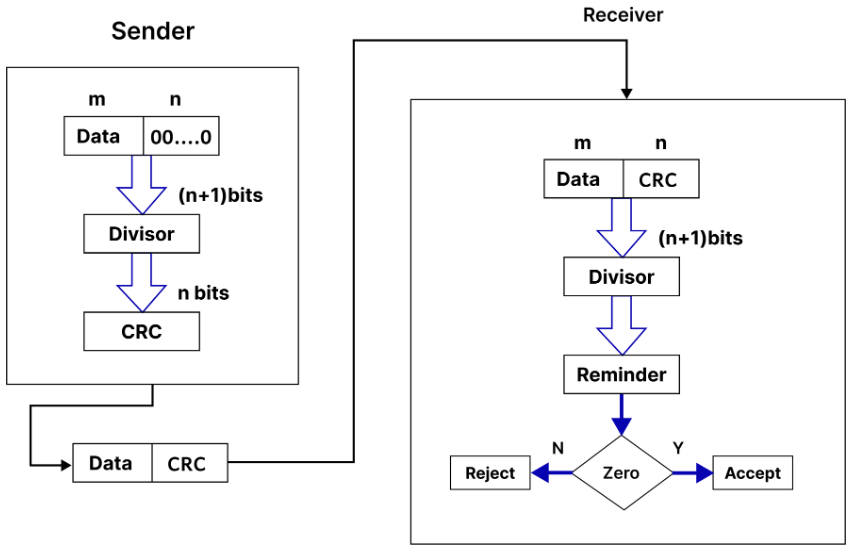

- **Cryptographic Hash-Based Checksums:** Advanced checksum methods use cryptographic hash functions, such as SHA-256, to ensure the highest level of data integrity. These are particularly important in secure communications where tampering or malicious changes must be detected.

## Turbo Codes: Theory and Simulation

### Python Simulation

In [ ]:
@dataclass
class SimulationConfig:
    debug: bool = True
    seed: int = 7
    iterations: tuple = (1, 2, 3, 4, 5, 6)

    turbo_memory: int = 2
    turbo_feedback_octal: int = 0o5
    turbo_feedforward_octal: int = 0o7

    conv_memory: int = 2
    conv_g0_octal: int = 0o7
    conv_g1_octal: int = 0o5

    block_size: int = 1024
    conv_ebn0_db: np.ndarray = field(default_factory=lambda: np.array([-4.0, -2.0, 0.0, 2.0, 4.0]))
    turbo_ebn0_db: np.ndarray = field(default_factory=lambda: np.array([-1.0, -0.5, 0.0, 0.5, 1.0, 1.3, 1.6]))

    conv_min_trials: int = 20
    conv_max_trials: int = 60
    conv_target_errors: int = 120

    turbo_min_blocks: int = 15
    turbo_max_blocks: int = 50
    turbo_target_errors: int = 80

    save_figures: bool = True
    output_prefix: str = "turbo_demo"

    @staticmethod
    def quick():
        return SimulationConfig()

    @staticmethod
    def full():
        return SimulationConfig(
            debug=False,
            block_size=1024,
            conv_ebn0_db=np.arange(-6.0, 5.0, 1.0),
            turbo_ebn0_db=np.arange(-1.0, 1.76, 0.25),
            conv_min_trials=80,
            conv_max_trials=300,
            conv_target_errors=300,
            turbo_min_blocks=60,
            turbo_max_blocks=400,
            turbo_target_errors=200,
            output_prefix="turbo_demo_full",
        )

def octal_poly_to_bits(poly_octal: int, memory: int) -> list:
    return [(int(poly_octal) >> i) & 1 for i in range(memory + 1)]


def build_rsc_trellis(memory: int, feedback_octal: int, feedforward_octal: int) -> dict:
    fb = octal_poly_to_bits(feedback_octal, memory)
    ff = octal_poly_to_bits(feedforward_octal, memory)
    if fb[0] != 1 or ff[0] != 1:
        raise ValueError("feedback and feedforward polynomials must have a non-zero D^0 term")

    n_states = 1 << memory
    next_state = np.zeros((n_states, 2), dtype=np.int32)
    parity = np.zeros((n_states, 2), dtype=np.int8)
    sys_sign = np.zeros((n_states, 2), dtype=np.float64)
    par_sign = np.zeros((n_states, 2), dtype=np.float64)

    for state in range(n_states):
        reg = [(state >> (memory - 1 - i)) & 1 for i in range(memory)]
        for u in (0, 1):
            x = u
            for i in range(1, memory + 1):
                if fb[i]:
                    x ^= reg[i - 1]

            p = x
            for i in range(1, memory + 1):
                if ff[i]:
                    p ^= reg[i - 1]

            new_reg = [x] + reg[:-1]
            ns = 0
            for bit in new_reg:
                ns = (ns << 1) | bit

            next_state[state, u] = ns
            parity[state, u] = p
            sys_sign[state, u] = 1.0 - 2.0 * u
            par_sign[state, u] = 1.0 - 2.0 * p

    return {
        "memory": memory,
        "n_states": n_states,
        "next_state": next_state,
        "parity": parity,
        "sys_sign": sys_sign,
        "par_sign": par_sign,
    }


def build_conv_trellis(memory: int, g0_octal: int, g1_octal: int) -> dict:
    g0 = octal_poly_to_bits(g0_octal, memory)
    g1 = octal_poly_to_bits(g1_octal, memory)
    n_states = 1 << memory
    next_state = np.zeros((n_states, 2), dtype=np.int32)
    out_bits = np.zeros((n_states, 2, 2), dtype=np.int8)
    out_sign = np.zeros((n_states, 2, 2), dtype=np.float64)

    for state in range(n_states):
        reg = [(state >> (memory - 1 - i)) & 1 for i in range(memory)]
        for u in (0, 1):
            c0 = u
            c1 = u
            for i in range(1, memory + 1):
                if g0[i]:
                    c0 ^= reg[i - 1]
                if g1[i]:
                    c1 ^= reg[i - 1]

            new_reg = [u] + reg[:-1]
            ns = 0
            for bit in new_reg:
                ns = (ns << 1) | bit

            next_state[state, u] = ns
            out_bits[state, u] = np.array([c0, c1], dtype=np.int8)
            out_sign[state, u] = np.array([1.0 - 2.0 * c0, 1.0 - 2.0 * c1], dtype=np.float64)

    return {
        "memory": memory,
        "n_states": n_states,
        "next_state": next_state,
        "out_bits": out_bits,
        "out_sign": out_sign,
    }

def rsc_encode(bits: np.ndarray, trellis: dict) -> tuple:
    bits = np.asarray(bits, dtype=np.int8)
    n = len(bits)
    sys = bits.copy()
    par = np.zeros(n, dtype=np.int8)
    state = 0
    for k, u in enumerate(bits):
        par[k] = trellis["parity"][state, u]
        state = trellis["next_state"][state, u]
    return sys, par


def conv_encode(bits: np.ndarray, trellis: dict, terminate: bool = True) -> np.ndarray:
    bits = np.asarray(bits, dtype=np.int8)
    if terminate:
        bits = np.concatenate([bits, np.zeros(trellis["memory"], dtype=np.int8)])

    state = 0
    out = []
    for u in bits:
        out.extend(trellis["out_bits"][state, u].tolist())
        state = trellis["next_state"][state, u]
    return np.asarray(out, dtype=np.int8)


def viterbi_decode_unquantized(received: np.ndarray, trellis: dict, n_info_bits: int, terminate: bool = True) -> np.ndarray:
    received = np.asarray(received, dtype=np.float64)
    n_steps = len(received) // 2
    n_states = trellis["n_states"]

    path_metric = np.full((n_steps + 1, n_states), 1e30, dtype=np.float64)
    prev_state = np.full((n_steps + 1, n_states), -1, dtype=np.int32)
    prev_input = np.full((n_steps + 1, n_states), -1, dtype=np.int8)
    path_metric[0, 0] = 0.0

    for k in range(n_steps):
        r = received[2 * k: 2 * k + 2]
        for state in range(n_states):
            metric = path_metric[k, state]
            if metric > 1e20:
                continue
            for u in (0, 1):
                ns = trellis["next_state"][state, u]
                expected = trellis["out_sign"][state, u]
                branch_metric = np.sum((r - expected) ** 2)
                cand = metric + branch_metric
                if cand < path_metric[k + 1, ns]:
                    path_metric[k + 1, ns] = cand
                    prev_state[k + 1, ns] = state
                    prev_input[k + 1, ns] = u

    state = 0 if terminate else int(np.argmin(path_metric[n_steps]))
    decoded = []
    for k in range(n_steps, 0, -1):
        u = int(prev_input[k, state])
        decoded.append(u)
        state = int(prev_state[k, state])
    decoded.reverse()
    return np.asarray(decoded[:n_info_bits], dtype=np.int8)


def bcjr_maxlog(llr_sys: np.ndarray, llr_par: np.ndarray, llr_apriori: np.ndarray, trellis: dict) -> tuple:
    llr_sys = np.asarray(llr_sys, dtype=np.float64)
    llr_par = np.asarray(llr_par, dtype=np.float64)
    llr_apriori = np.asarray(llr_apriori, dtype=np.float64)

    n = len(llr_sys)
    n_states = trellis["n_states"]
    next_state = trellis["next_state"]
    sys_sign = trellis["sys_sign"]
    par_sign = trellis["par_sign"]

    neg_inf = -1e30
    alpha = np.full((n + 1, n_states), neg_inf, dtype=np.float64)
    beta = np.full((n + 1, n_states), neg_inf, dtype=np.float64)
    alpha[0, 0] = 0.0
    beta[n, :] = 0.0

    for k in range(n):
        for state in range(n_states):
            a = alpha[k, state]
            if a < neg_inf / 10:
                continue
            for u in (0, 1):
                ns = next_state[state, u]
                gamma = 0.5 * (llr_apriori[k] + llr_sys[k]) * sys_sign[state, u]
                gamma += 0.5 * llr_par[k] * par_sign[state, u]
                val = a + gamma
                if val > alpha[k + 1, ns]:
                    alpha[k + 1, ns] = val

    for k in range(n - 1, -1, -1):
        for state in range(n_states):
            best = neg_inf
            for u in (0, 1):
                ns = next_state[state, u]
                gamma = 0.5 * (llr_apriori[k] + llr_sys[k]) * sys_sign[state, u]
                gamma += 0.5 * llr_par[k] * par_sign[state, u]
                val = beta[k + 1, ns] + gamma
                if val > best:
                    best = val
            beta[k, state] = best

    llr_post = np.zeros(n, dtype=np.float64)
    for k in range(n):
        best0 = neg_inf
        best1 = neg_inf
        for state in range(n_states):
            a = alpha[k, state]
            if a < neg_inf / 10:
                continue
            for u in (0, 1):
                ns = next_state[state, u]
                gamma = 0.5 * (llr_apriori[k] + llr_sys[k]) * sys_sign[state, u]
                gamma += 0.5 * llr_par[k] * par_sign[state, u]
                val = a + gamma + beta[k + 1, ns]
                if u == 0:
                    if val > best0:
                        best0 = val
                else:
                    if val > best1:
                        best1 = val
        llr_post[k] = best0 - best1

    llr_ext = llr_post - llr_sys - llr_apriori
    return llr_post, llr_ext

def turbo_encode(bits: np.ndarray, interleaver: np.ndarray, trellis: dict) -> tuple:
    bits = np.asarray(bits, dtype=np.int8)
    sys, par1 = rsc_encode(bits, trellis)
    _, par2 = rsc_encode(bits[interleaver], trellis)
    return sys, par1, par2


def turbo_decode_maxlog(
    rx_sys: np.ndarray,
    rx_par1: np.ndarray,
    rx_par2: np.ndarray,
    sigma2: float,
    interleaver: np.ndarray,
    trellis: dict,
    n_iterations: int,
) -> tuple:
    llr_scale = 2.0 / sigma2
    llr_sys = llr_scale * np.asarray(rx_sys, dtype=np.float64)
    llr_par1 = llr_scale * np.asarray(rx_par1, dtype=np.float64)
    llr_par2 = llr_scale * np.asarray(rx_par2, dtype=np.float64)

    deinterleaver = np.argsort(interleaver)
    llr_apriori_1 = np.zeros_like(llr_sys)
    llr_per_iteration = []

    for _ in range(n_iterations):
        _, llr_ext_1 = bcjr_maxlog(llr_sys, llr_par1, llr_apriori_1, trellis)
        llr_apriori_2 = llr_ext_1[interleaver]

        llr_post_2_int, llr_ext_2_int = bcjr_maxlog(
            llr_sys[interleaver], llr_par2, llr_apriori_2, trellis
        )

        llr_final = llr_post_2_int[deinterleaver]
        llr_per_iteration.append(llr_final.copy())
        llr_apriori_1 = llr_ext_2_int[deinterleaver]

    hard_bits = (llr_per_iteration[-1] < 0.0).astype(np.int8)
    return hard_bits, llr_per_iteration

def awgn_sigma2(ebn0_db: float, code_rate: float) -> float:
    return 1.0 / (2.0 * code_rate * 10.0 ** (ebn0_db / 10.0))


def simulate_convolutional(cfg: SimulationConfig, rng: np.random.Generator, conv_trellis: dict) -> np.ndarray:
    ber = []
    for ebn0_db in cfg.conv_ebn0_db:
        sigma2 = awgn_sigma2(ebn0_db, code_rate=0.5)
        sigma = np.sqrt(sigma2)

        total_errors = 0
        total_bits = 0
        trial = 0
        while trial < cfg.conv_min_trials or (
            total_errors < cfg.conv_target_errors and trial < cfg.conv_max_trials
        ):
            bits = rng.integers(0, 2, cfg.block_size, dtype=np.int8)
            coded = conv_encode(bits, conv_trellis, terminate=True)
            tx = 1.0 - 2.0 * coded
            rx = tx + sigma * rng.standard_normal(len(tx))
            dec = viterbi_decode_unquantized(rx, conv_trellis, cfg.block_size, terminate=True)

            total_errors += int(np.sum(bits != dec))
            total_bits += cfg.block_size
            trial += 1

        ber_value = total_errors / max(total_bits, 1)
        ber.append(ber_value)
        print(f"[conv] Eb/N0={ebn0_db:5.2f} dB  BER={ber_value:.4e}  trials={trial}")
    return np.asarray(ber, dtype=np.float64)


def simulate_turbo(cfg: SimulationConfig, rng: np.random.Generator, turbo_trellis: dict) -> tuple:
    interleaver = rng.permutation(cfg.block_size)
    results = {it: [] for it in cfg.iterations}
    llr_snapshot = {it: None for it in cfg.iterations}

    for ebn0_db in cfg.turbo_ebn0_db:
        sigma2 = awgn_sigma2(ebn0_db, code_rate=1.0 / 3.0)
        sigma = np.sqrt(sigma2)
        error_count = {it: 0 for it in cfg.iterations}
        blocks = 0
        total_bits = 0

        while blocks < cfg.turbo_min_blocks or (
            error_count[max(cfg.iterations)] < cfg.turbo_target_errors and blocks < cfg.turbo_max_blocks
        ):
            bits = rng.integers(0, 2, cfg.block_size, dtype=np.int8)
            sys, par1, par2 = turbo_encode(bits, interleaver, turbo_trellis)

            tx_sys = 1.0 - 2.0 * sys
            tx_par1 = 1.0 - 2.0 * par1
            tx_par2 = 1.0 - 2.0 * par2

            rx_sys = tx_sys + sigma * rng.standard_normal(cfg.block_size)
            rx_par1 = tx_par1 + sigma * rng.standard_normal(cfg.block_size)
            rx_par2 = tx_par2 + sigma * rng.standard_normal(cfg.block_size)

            _, llr_iters = turbo_decode_maxlog(
                rx_sys, rx_par1, rx_par2, sigma2, interleaver, turbo_trellis, max(cfg.iterations)
            )

            for it in cfg.iterations:
                hard = (llr_iters[it - 1] < 0.0).astype(np.int8)
                error_count[it] += int(np.sum(bits != hard))

            if ebn0_db == cfg.turbo_ebn0_db[-1] and blocks == 0:
                for it in cfg.iterations:
                    llr_snapshot[it] = llr_iters[it - 1][:20].copy()

            total_bits += cfg.block_size
            blocks += 1

        for it in cfg.iterations:
            ber_value = error_count[it] / max(total_bits, 1)
            results[it].append(ber_value)

        print(
            f"[turbo] Eb/N0={ebn0_db:5.2f} dB  blocks={blocks}  "
            + ", ".join([f"iter {it}: {results[it][-1]:.4e}" for it in cfg.iterations])
        )

    for it in cfg.iterations:
        results[it] = np.asarray(results[it], dtype=np.float64)
    return interleaver, results, llr_snapshot

def plot_results(cfg: SimulationConfig, ber_conv: np.ndarray, turbo_results: dict, llr_snapshot: dict) -> None:
    floor = 1e-6 if cfg.debug else 1e-8

    plt.figure(figsize=(7, 4.8))
    uncoded = 0.5 * erfc(np.sqrt(10.0 ** (cfg.conv_ebn0_db / 10.0)))
    plt.semilogy(cfg.conv_ebn0_db, np.clip(uncoded, floor, None), "rx-", label="Uncoded BPSK")
    plt.semilogy(cfg.conv_ebn0_db, np.clip(ber_conv, floor, None), "bo-", label="Conv. coded")
    plt.xlabel("Eb/N0 (dB)")
    plt.ylabel("BER")
    plt.title("BPSK, rate-1/2 convolutional code, soft Viterbi decoding")
    plt.grid(True, which="both", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    if cfg.save_figures:
        plt.savefig(f"{cfg.output_prefix}_conv.png", dpi=160)
    plt.show()

    plt.figure(figsize=(7, 4.8))
    for it in cfg.iterations:
        plt.semilogy(
            cfg.turbo_ebn0_db,
            np.clip(turbo_results[it], floor, None),
            marker="x",
            label=f"Iteration {it}",
        )
    plt.xlabel("Eb/N0 (dB)")
    plt.ylabel("BER")
    plt.title("BPSK, rate-1/3 turbo code, iterative max-log-MAP decoding")
    plt.grid(True, which="both", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    if cfg.save_figures:
        plt.savefig(f"{cfg.output_prefix}_turbo.png", dpi=160)
    plt.show()

    if any(v is not None for v in llr_snapshot.values()):
        plt.figure(figsize=(8.5, 5.5))
        for it in cfg.iterations:
            if llr_snapshot[it] is not None:
                plt.scatter(np.arange(len(llr_snapshot[it])), llr_snapshot[it], s=18, label=f"Iteration {it}")
        plt.xlabel("Bit index")
        plt.ylabel("Posterior LLR")
        plt.title("Turbo decoder soft outputs over iterations")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend()
        plt.tight_layout()
        if cfg.save_figures:
            plt.savefig(f"{cfg.output_prefix}_llr.png", dpi=160)
        plt.show()

def run(cfg: SimulationConfig) -> None:
    rng = np.random.default_rng(cfg.seed)
    conv_trellis = build_conv_trellis(cfg.conv_memory, cfg.conv_g0_octal, cfg.conv_g1_octal)
    turbo_trellis = build_rsc_trellis(cfg.turbo_memory, cfg.turbo_feedback_octal, cfg.turbo_feedforward_octal)

    print("Running with configuration:")
    print(cfg)
    print()

    ber_conv = simulate_convolutional(cfg, rng, conv_trellis)
    _, turbo_results, llr_snapshot = simulate_turbo(cfg, rng, turbo_trellis)
    plot_results(cfg, ber_conv, turbo_results, llr_snapshot)


if __name__ == "__main__":
    t0 = time.time()
    
    # config = SimulationConfig.quick()
    config = SimulationConfig.full()

    run(config)
    print(f"Elapsed: {time.time() - t0:.2f} s")

## LDPC Codes

## Comparative Analysis

## Conclusion

## References